# 02 · Image embeddings

CLIP image embeddings projected to 256-d. How well do they separate listings of the same product from different products?

Requires `python scripts/build_embeddings.py`.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import src  # noqa: F401  (sets macOS OpenMP workaround before torch/faiss)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils.config import load_config
config = load_config()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "axes.axisbelow": True})
SAME, DIFF = "#2a78d6", "#eb6834"  # fixed categorical slots 1 and 2

In [2]:
from src.embeddings.store import EmbeddingStore, embeddings_dir
store = EmbeddingStore.load(embeddings_dir(config))
labels = pd.factorize(store.metadata.label_group)[0]
print(store.manifest['image_model'], 'raw', store.image_raw.shape, '-> projected', store.image.shape)
print('unit norm:', np.allclose(np.linalg.norm(store.image[store.image_mask], axis=1), 1, atol=1e-5))

openai/clip-vit-base-patch32 raw (144, 512) -> projected (144, 256)
unit norm: True


## Does the orthogonal projection preserve similarity?
Compare pairwise cosine similarities before (512-d) and after (256-d) projection.

In [3]:
raw = store.image_raw / np.linalg.norm(store.image_raw, axis=1, keepdims=True)
iu = np.triu_indices(len(raw), 1)
before, after = (raw @ raw.T)[iu], (store.image @ store.image.T)[iu]
print(f'Pearson r = {np.corrcoef(before, after)[0, 1]:.3f}, mean |diff| = {np.abs(before - after).mean():.3f}')

Pearson r = 0.978, mean |diff| = 0.015


In [4]:
def same_vs_diff(emb, mask, labels):
    """Cosine similarities of same-group vs different-group pairs (both rows valid)."""
    idx = np.flatnonzero(mask)
    sims = emb[idx] @ emb[idx].T
    same = labels[idx][:, None] == labels[idx][None, :]
    iu = np.triu_indices(len(idx), k=1)
    return sims[iu][same[iu]], sims[iu][~same[iu]]

def plot_hist(same, diff, title):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    bins = np.linspace(min(diff.min(), same.min()), 1, 40)
    ax.hist(diff, bins=bins, density=True, alpha=0.6, color=DIFF, label=f"different product (n={len(diff)})")
    ax.hist(same, bins=bins, density=True, alpha=0.6, color=SAME, label=f"same product (n={len(same)})")
    ax.set_xlabel("cosine similarity"); ax.set_ylabel("density"); ax.set_title(title, loc="left")
    ax.legend(frameon=False); plt.show()

same-product mean 0.890  |  different-product mean 0.724


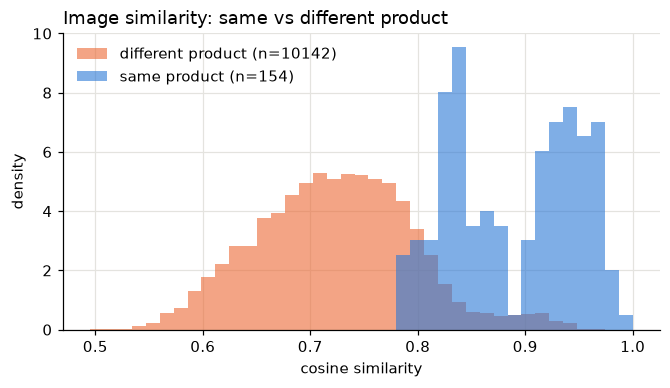

In [5]:
same, diff = same_vs_diff(store.image, store.image_mask, labels)
print(f'same-product mean {same.mean():.3f}  |  different-product mean {diff.mean():.3f}')
plot_hist(same, diff, 'Image similarity: same vs different product')

## Nearest neighbours of one listing (image only)

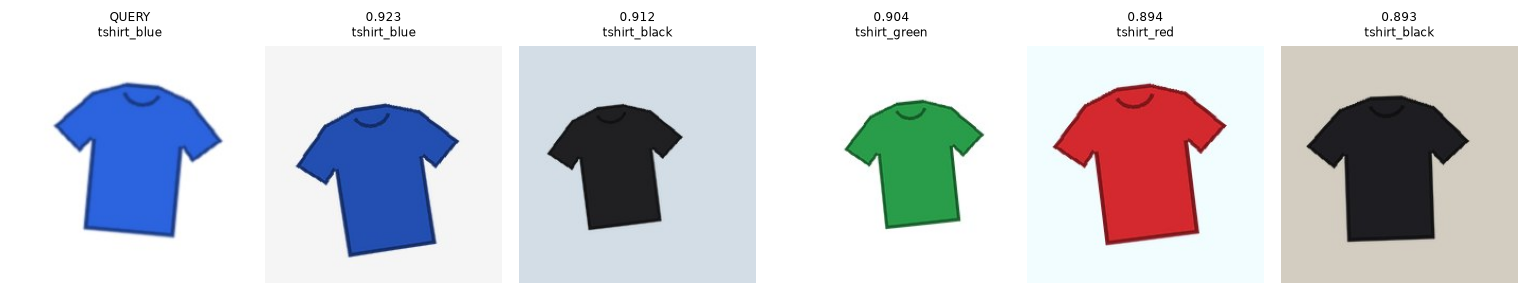

In [6]:
from src.retrieval.faiss_index import FaissIndex
from src.data.preprocessing import load_image
index = FaissIndex.build(store.image)
q = 2
scores, ids = index.search(store.image[q], 6)
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, i, s in zip(axes, ids[0], scores[0]):
    r = store.metadata.iloc[i]; ax.imshow(load_image(r.image_file)); ax.axis('off')
    ax.set_title(('QUERY' if i == q else f'{s:.3f}') + f'\n{r.label_group}', fontsize=8)
plt.tight_layout(); plt.show()

Colour variants of the same product type score high on image similarity alone. Titles carry complementary evidence (brand, model code, colour word).